変形開始
ノード数 = 100, 初期確率 p = 0.04, 段階数 = 20
rewires_per_step = 1000, beta = 1.8
[途中経過] 段階 1/20 : alpha = 0.05
[途中経過] 段階 2/20 : alpha = 0.10
[途中経過] 段階 3/20 : alpha = 0.15
[途中経過] 段階 4/20 : alpha = 0.20
[途中経過] 段階 5/20 : alpha = 0.25
[途中経過] 段階 6/20 : alpha = 0.30
[途中経過] 段階 7/20 : alpha = 0.35
[途中経過] 段階 8/20 : alpha = 0.40
[途中経過] 段階 9/20 : alpha = 0.45
[途中経過] 段階 10/20 : alpha = 0.50
[途中経過] 段階 11/20 : alpha = 0.55
[途中経過] 段階 12/20 : alpha = 0.60
[途中経過] 段階 13/20 : alpha = 0.65
[途中経過] 段階 14/20 : alpha = 0.70
[途中経過] 段階 15/20 : alpha = 0.75
[途中経過] 段階 16/20 : alpha = 0.80
[途中経過] 段階 17/20 : alpha = 0.85
[途中経過] 段階 18/20 : alpha = 0.90
[途中経過] 段階 19/20 : alpha = 0.95
[途中経過] 段階 20/20 : alpha = 1.00
描画開始: グラフ構造


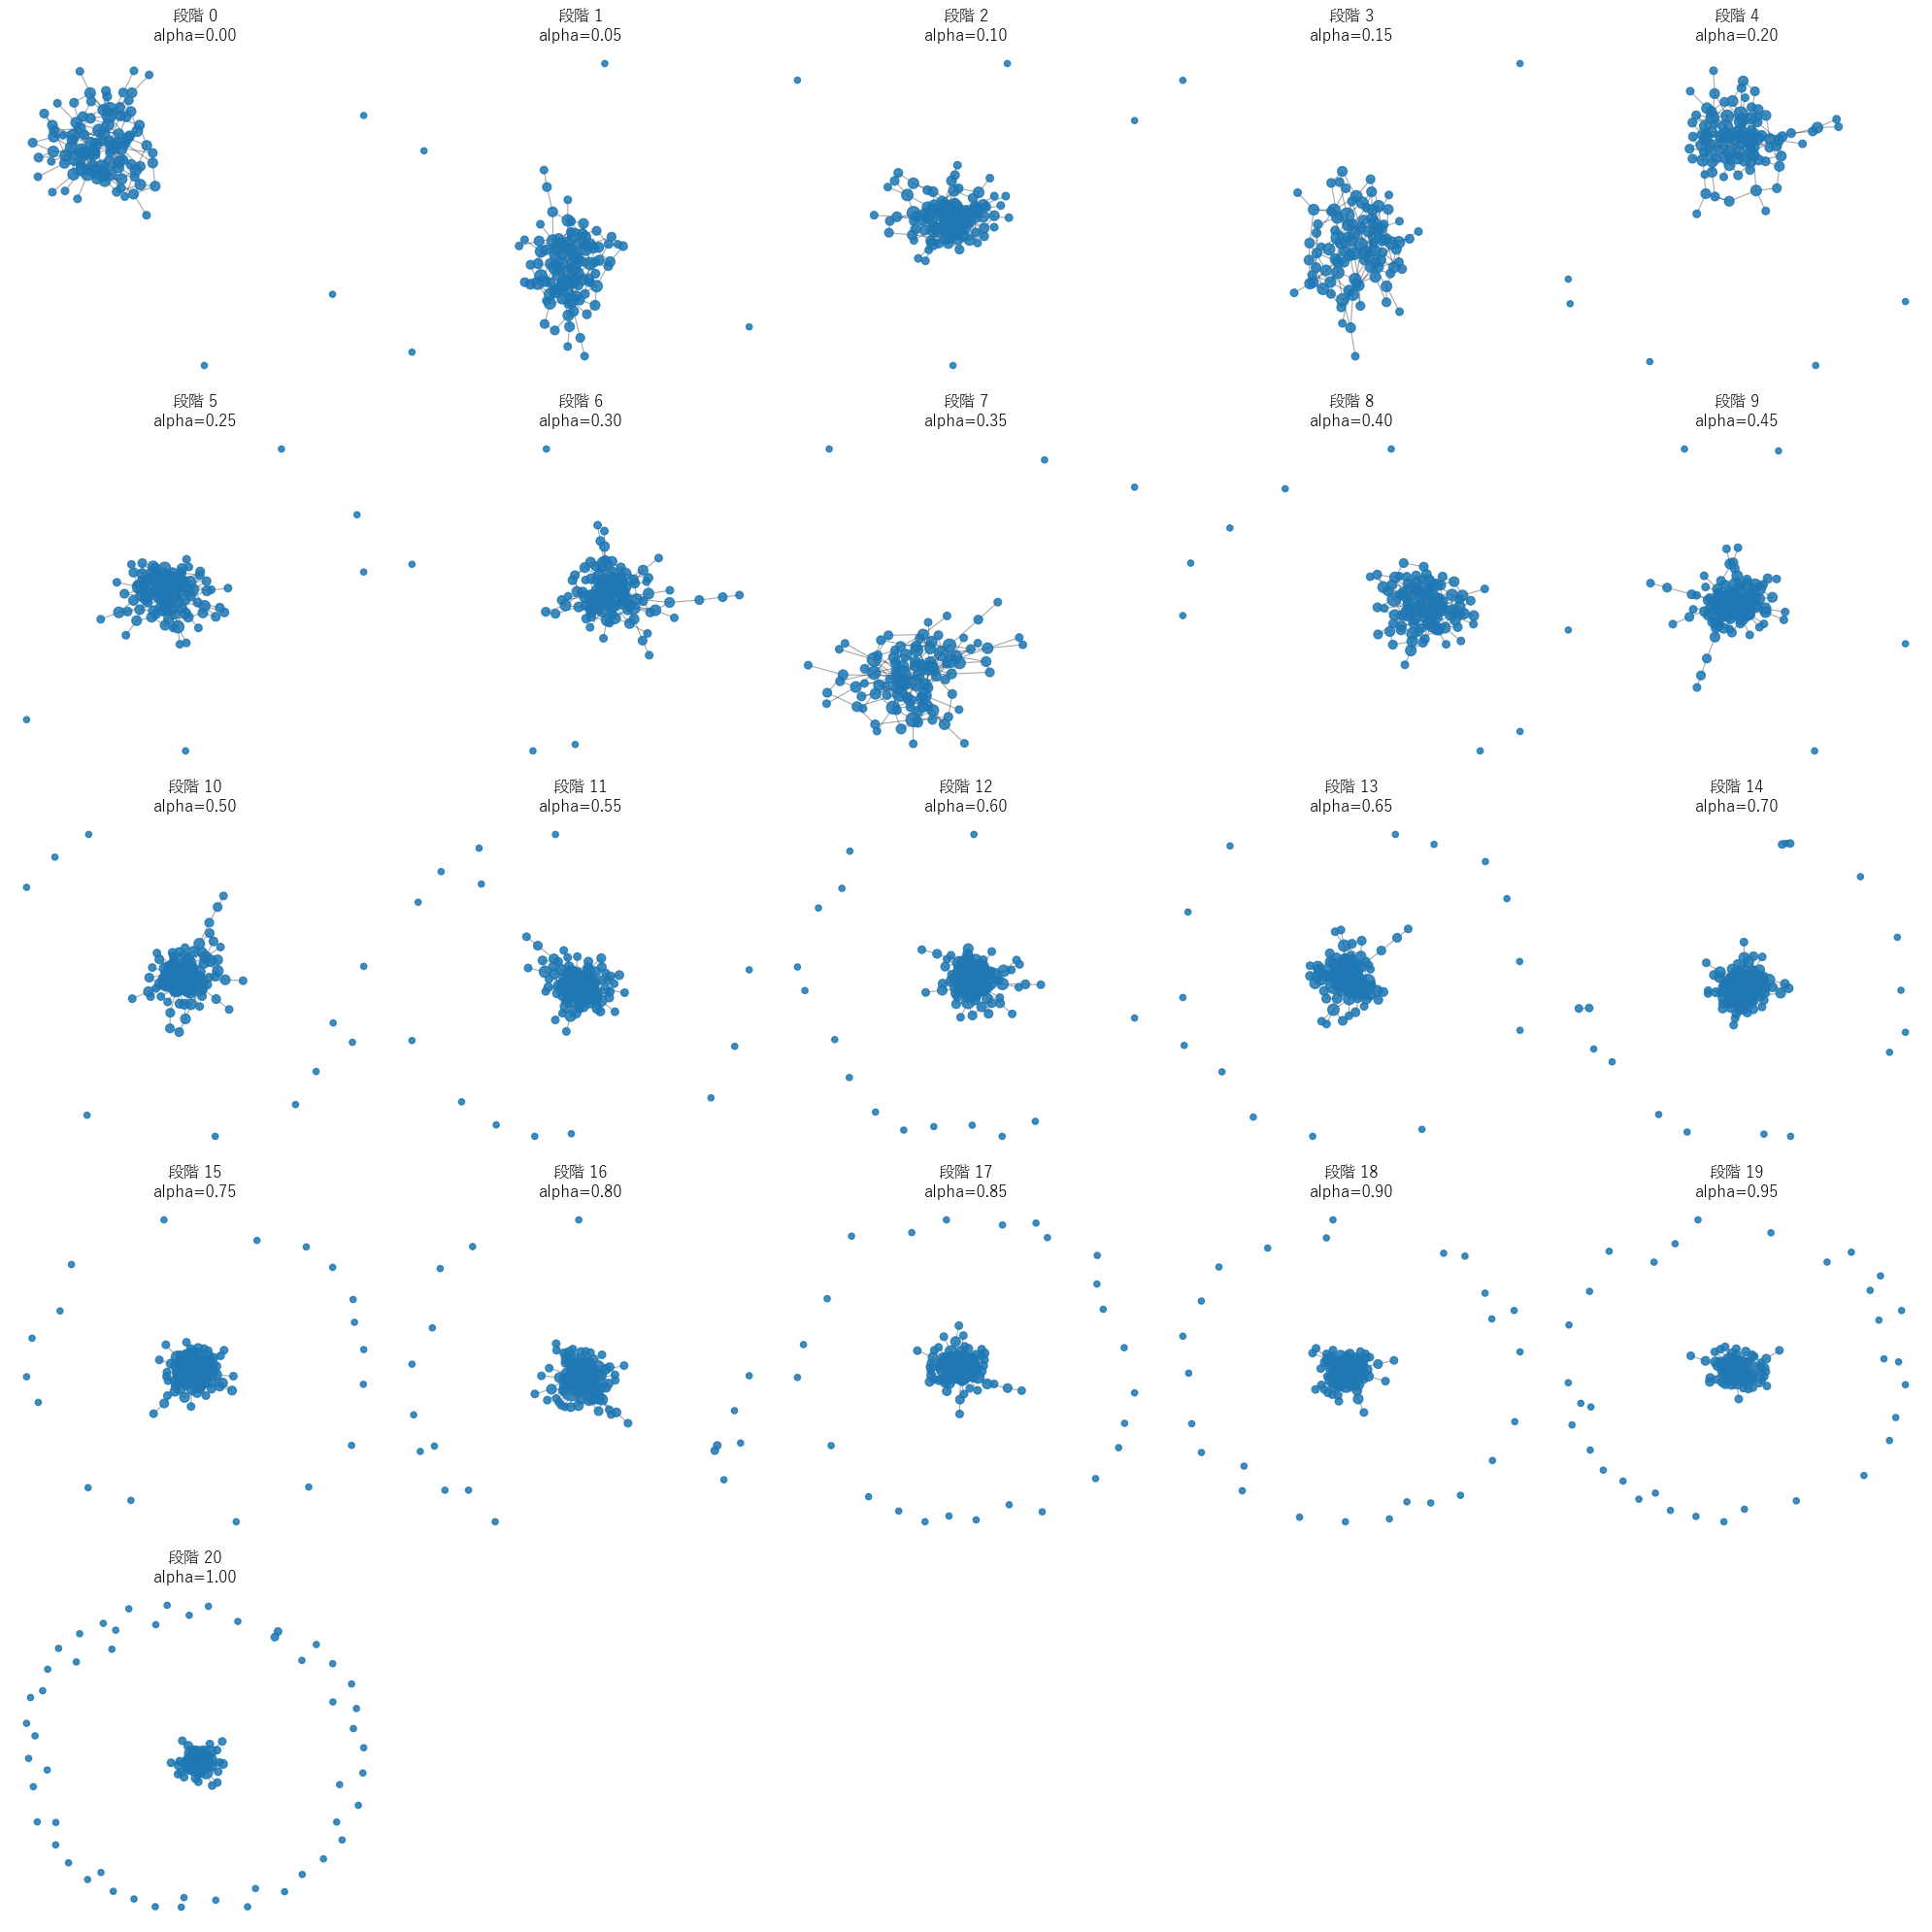

描画開始: 次数ヒストグラム


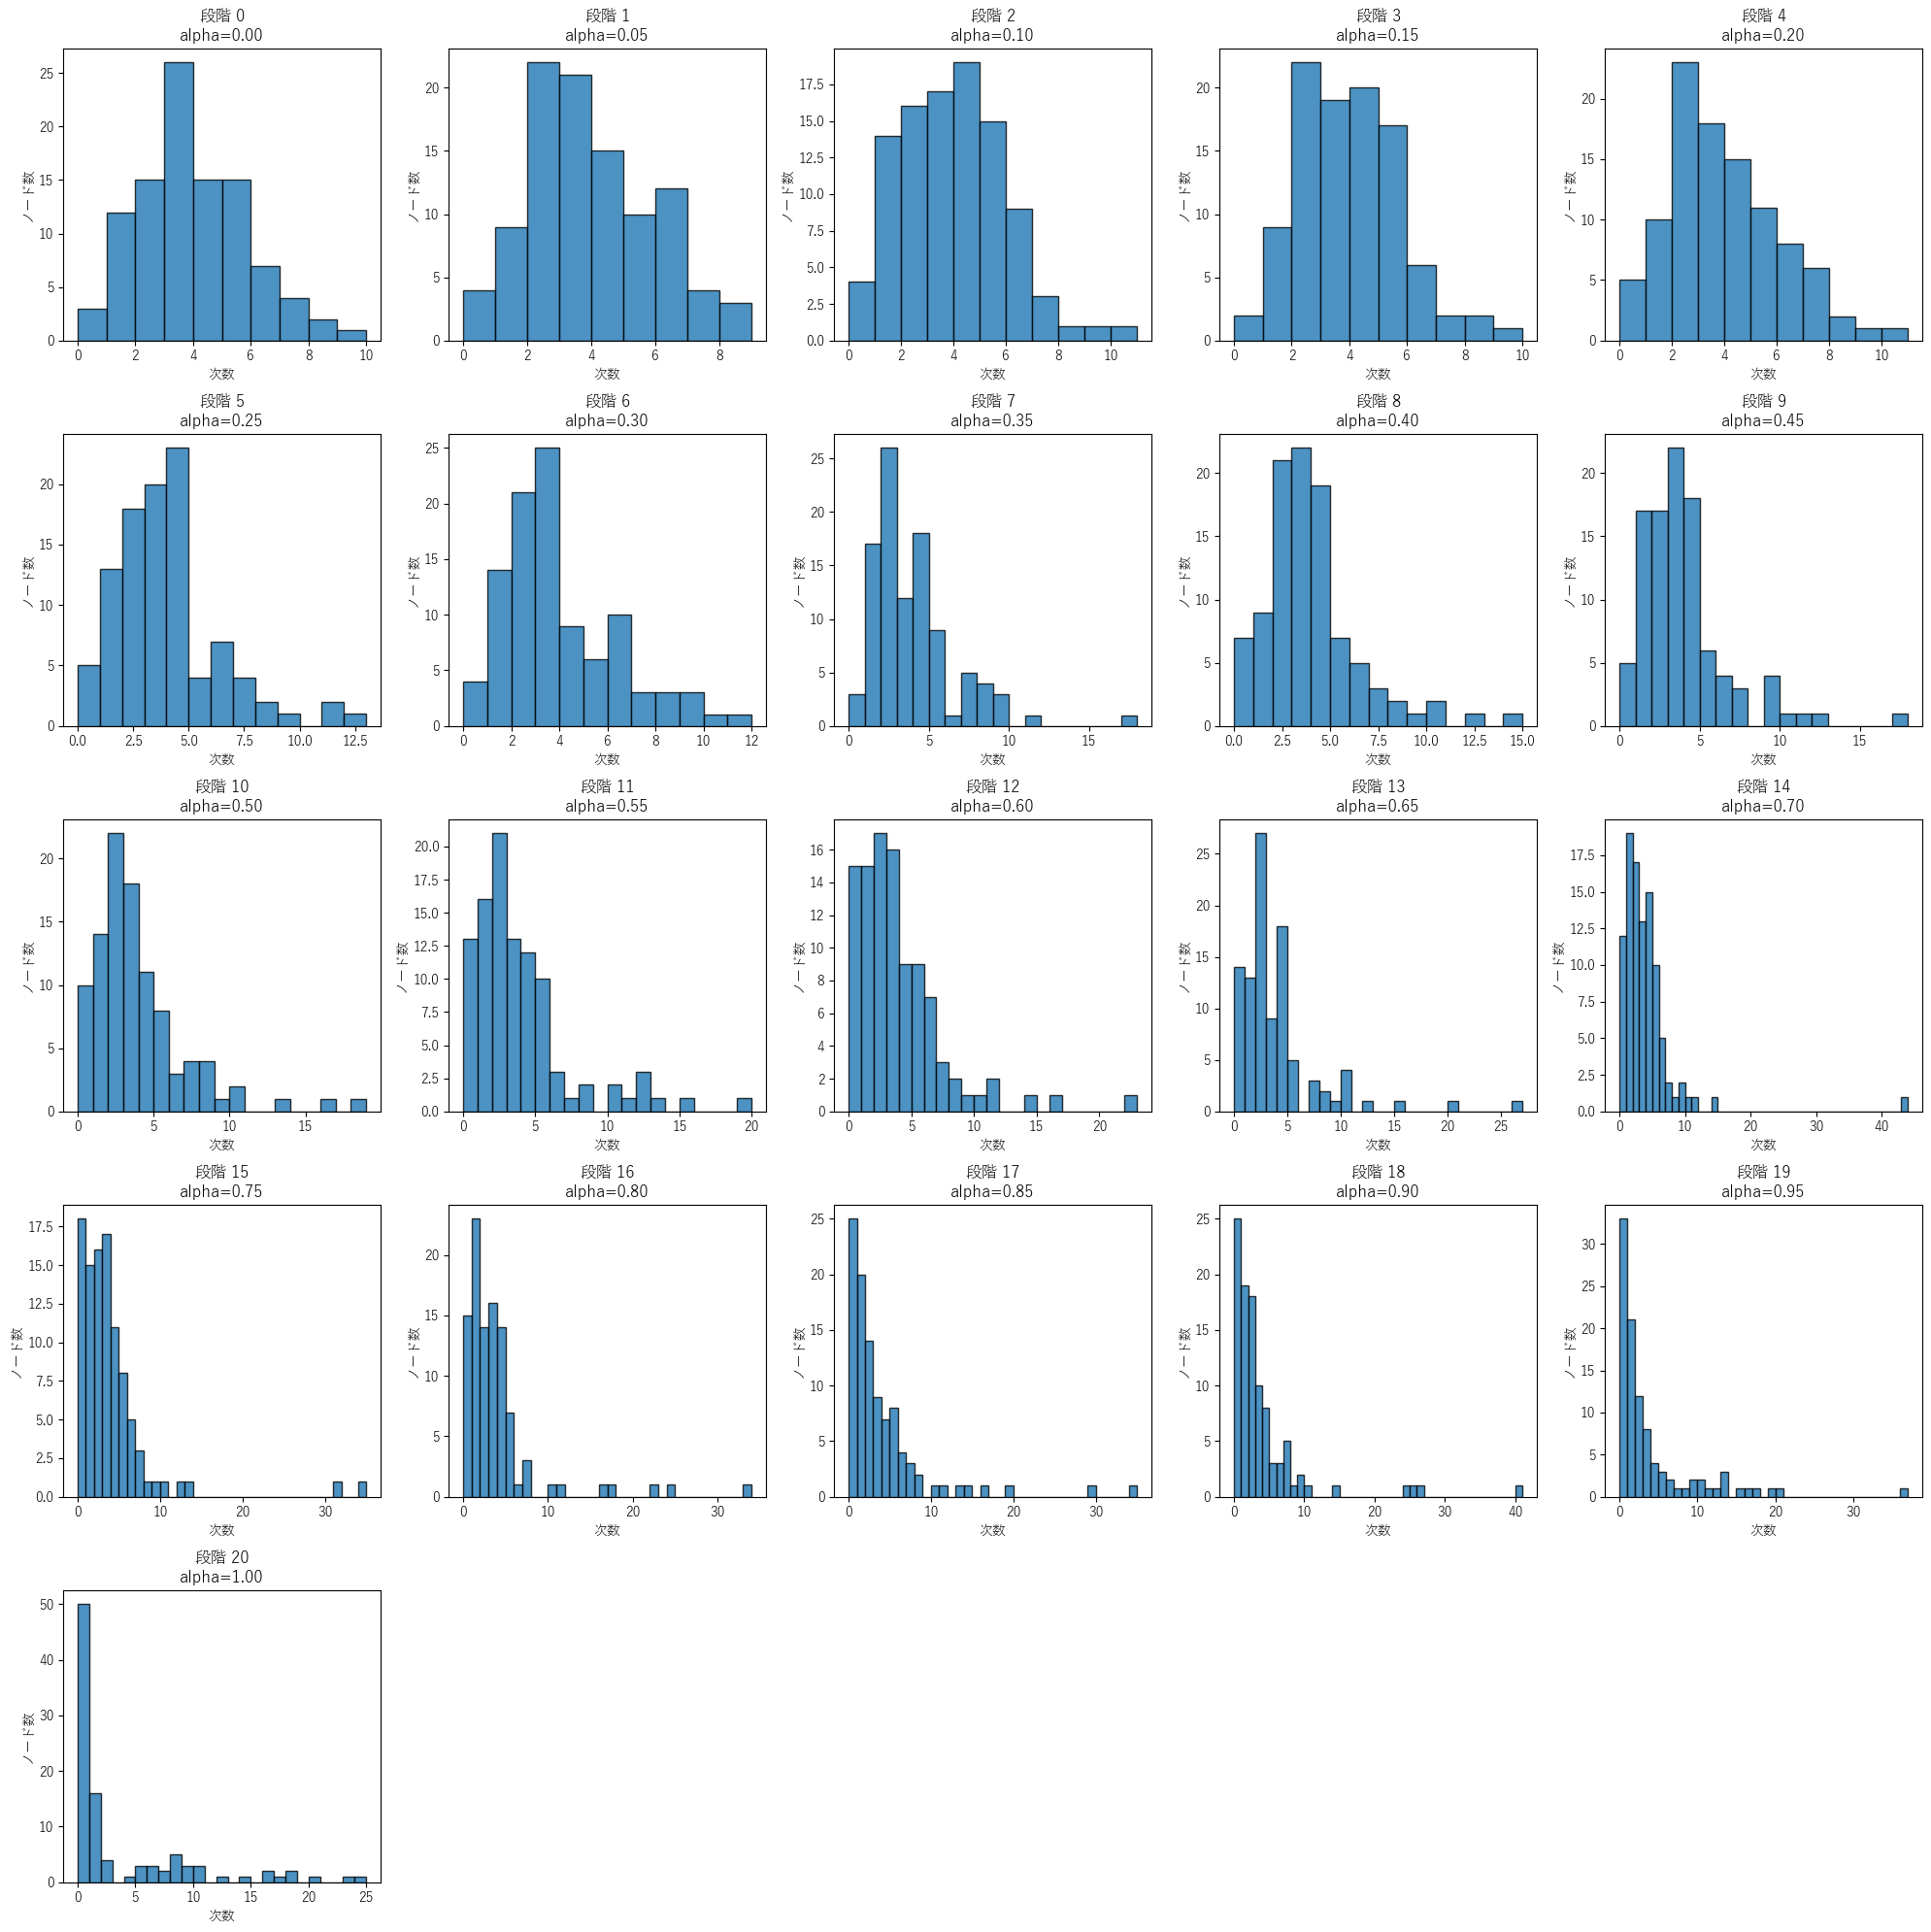

描画開始: 次数順位プロット


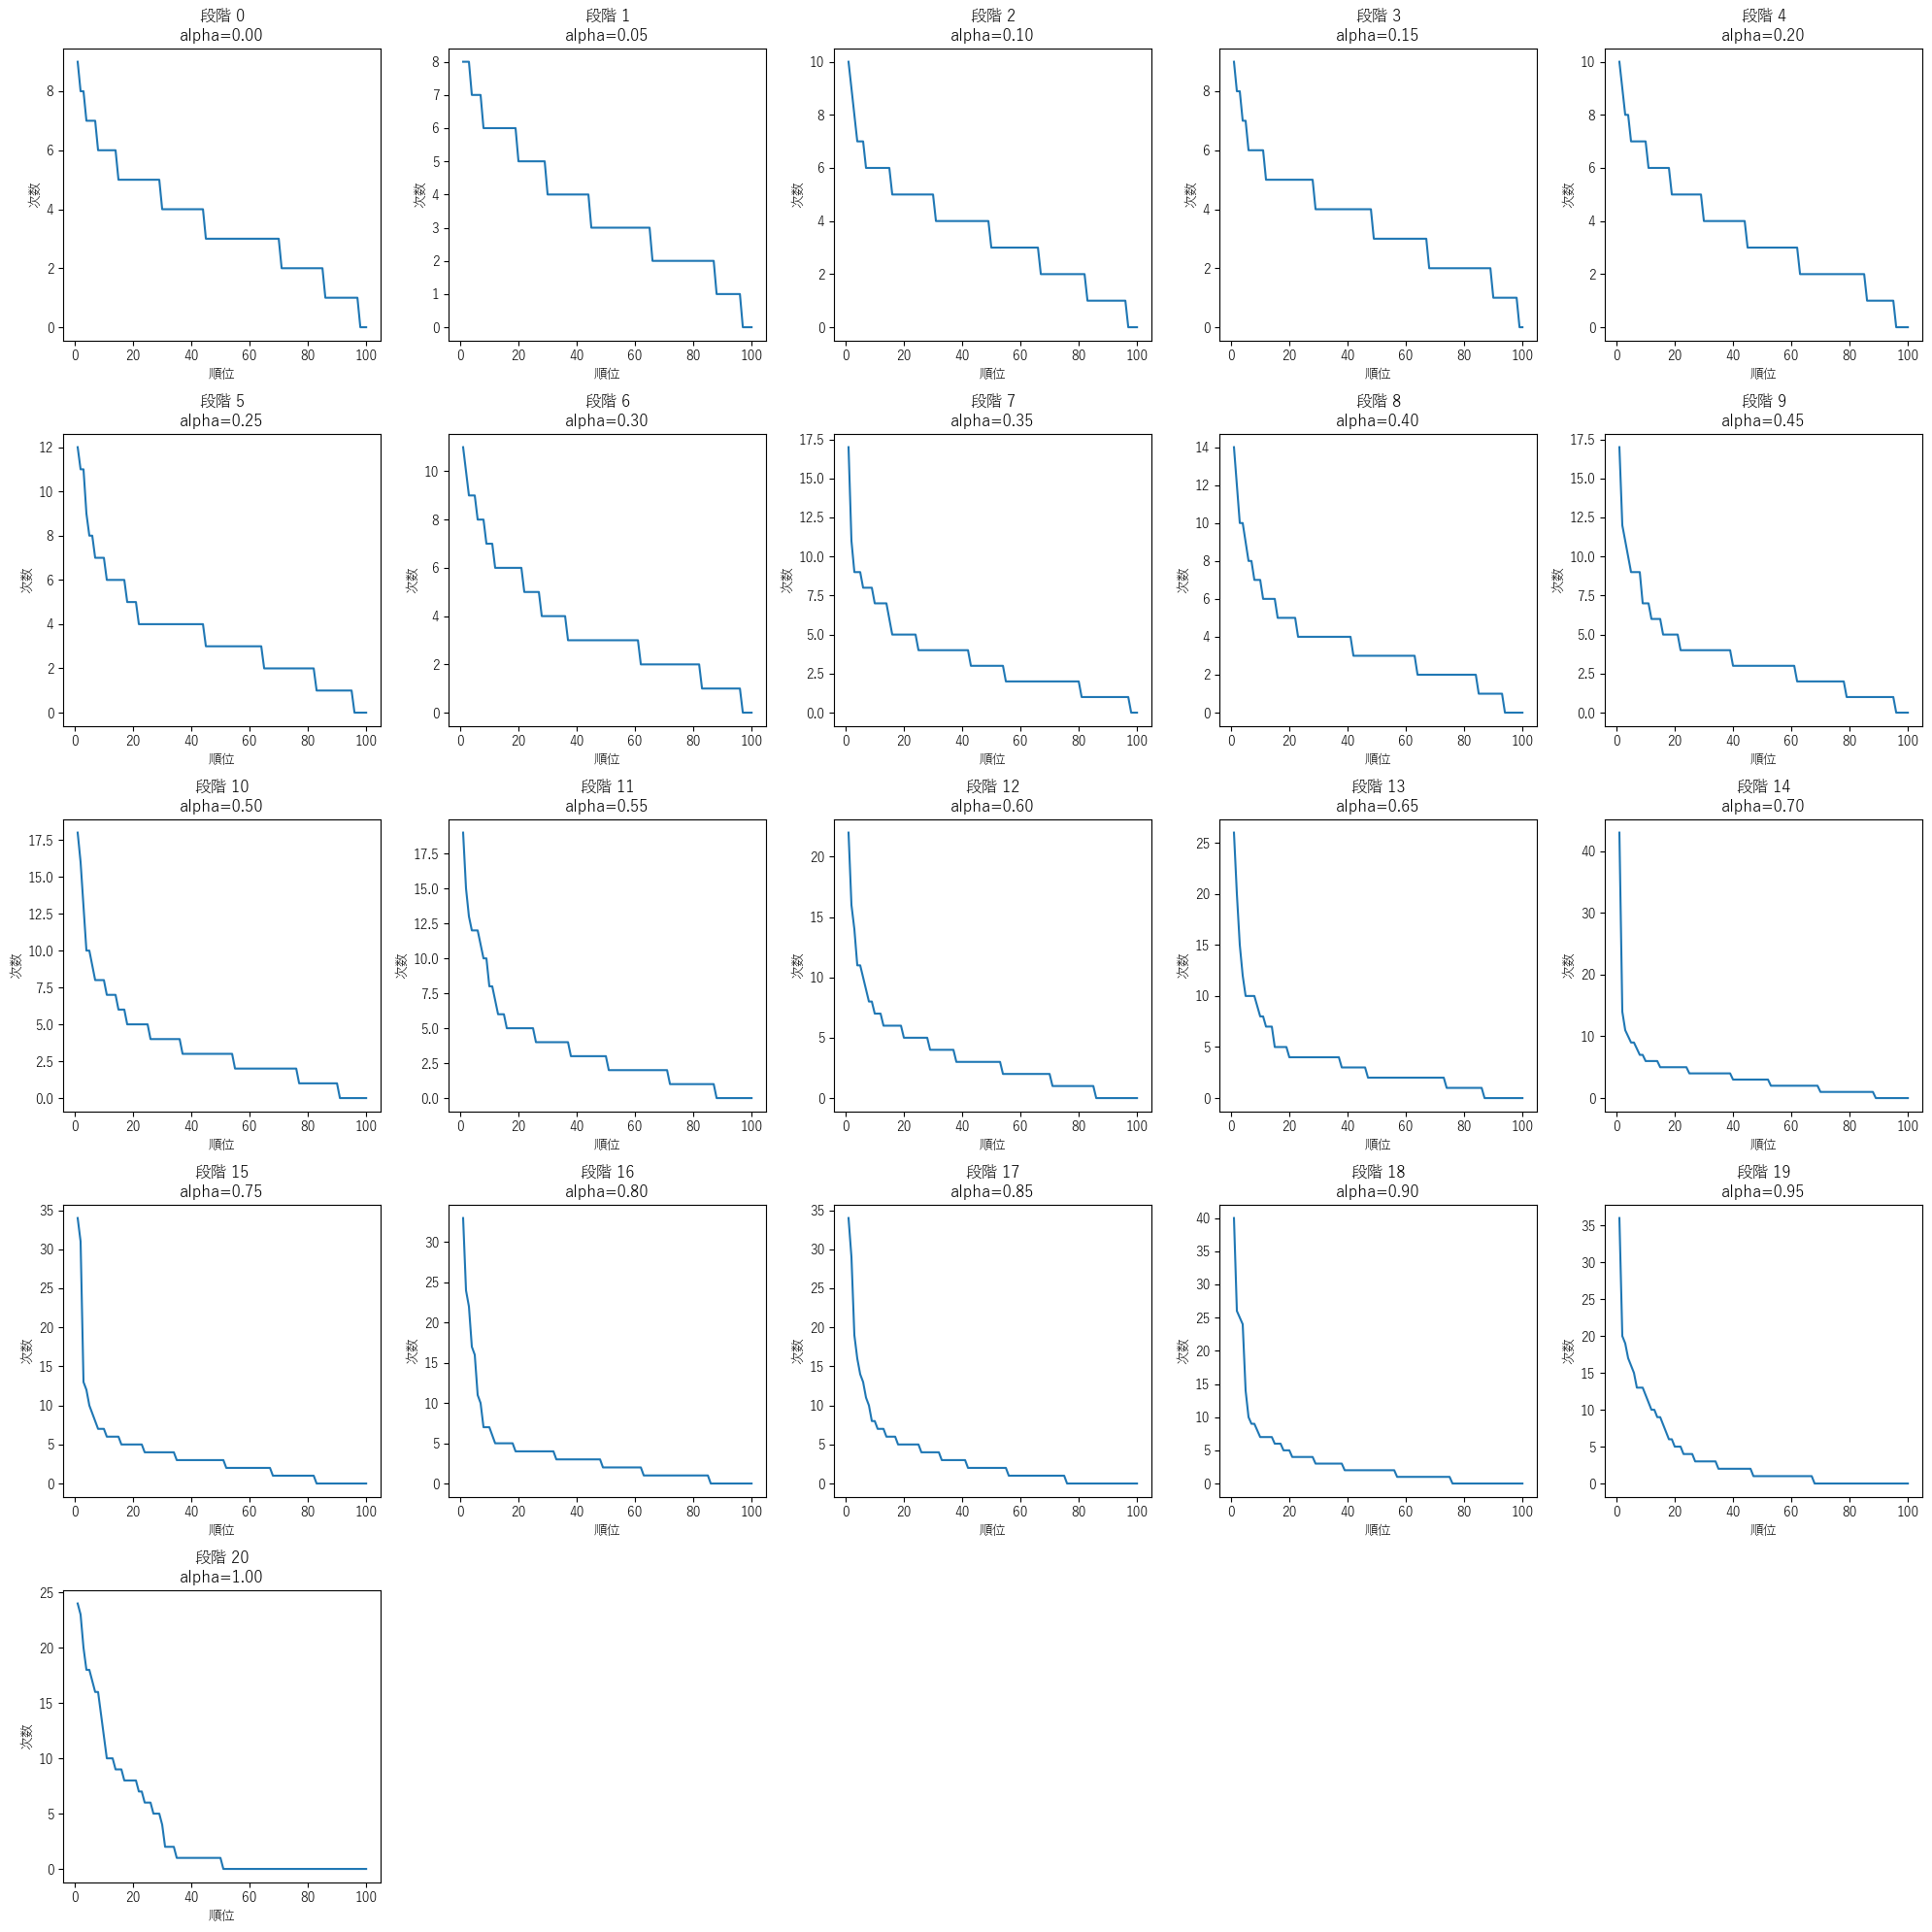

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.font_manager as fm


# =========================
# 日本語フォント設定
# =========================
def set_japanese_font():
    candidates = ["Yu Gothic", "MS Gothic", "Hiragino Sans", "IPAPGothic"]
    available = {f.name for f in fm.fontManager.ttflist}
    for c in candidates:
        if c in available:
            plt.rcParams["font.family"] = c
            return
    print("[WARNING] 日本語フォントが見つかりません。必要なら英語タイトルにしてください。")


set_japanese_font()


# =========================
# 基本設定
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


# =========================
# ノード選択
# =========================
def choose_node_uniform(G):
    return random.choice(list(G.nodes()))


def choose_node_preferential(G, beta=1.5):
    """
    次数に比例してノードを選ぶ。
    beta > 1 にすると高次数ノードをより強く優遇する。
    """
    nodes = list(G.nodes())
    deg = np.array([G.degree(n) + 1 for n in nodes], dtype=float)
    weights = deg ** beta
    weights /= weights.sum()
    return np.random.choice(nodes, p=weights)


def choose_node_mixed(G, alpha, beta=1.5):
    """
    alpha=0 なら一様ランダム
    alpha=1 なら次数比例（強め）
    """
    if random.random() < alpha:
        return choose_node_preferential(G, beta=beta)
    return choose_node_uniform(G)


# =========================
# スケールフリー寄りへ張り替え
# =========================
def rewire_graph_toward_scale_free(G, alpha, rewires_per_step=800, beta=1.5):
    """
    既存の辺を削除し、新しい辺を追加する。
    alpha が大きいほど、高次数ノードに辺が集中しやすい。
    beta を大きくすると、さらにハブ集中が強くなる。
    """
    G = G.copy()

    for _ in range(rewires_per_step):
        edges = list(G.edges())
        if not edges:
            break

        # 既存辺を1本削除
        u_old, v_old = random.choice(edges)
        G.remove_edge(u_old, v_old)

        # 新しい辺を1本追加
        added = False
        for _ in range(200):
            u = choose_node_mixed(G, alpha=alpha, beta=beta)
            v = choose_node_mixed(G, alpha=alpha, beta=beta)

            if u == v:
                continue
            if G.has_edge(u, v):
                continue

            G.add_edge(u, v)
            added = True
            break

        # 失敗したら元に戻す
        if not added and not G.has_edge(u_old, v_old) and u_old != v_old:
            G.add_edge(u_old, v_old)

    return G


# =========================
# 描画
# =========================
def plot_transition(graphs, alphas):
    ncols = 5
    nrows = int(np.ceil(len(graphs) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (G, alpha) in enumerate(zip(graphs, alphas)):
        ax = axes[i]
        pos = nx.spring_layout(G, seed=SEED)

        deg = np.array([G.degree(n) for n in G.nodes()])
        node_sizes = 20 + deg * 10

        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_size=node_sizes,
            alpha=0.85
        )
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            alpha=0.35,
            width=0.8
        )

        ax.set_title(f"段階 {i}\nalpha={alpha:.2f}")
        ax.axis("off")

    for j in range(len(graphs), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def plot_degree_distributions(graphs, alphas):
    ncols = 5
    nrows = int(np.ceil(len(graphs) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (G, alpha) in enumerate(zip(graphs, alphas)):
        ax = axes[i]
        deg = [G.degree(n) for n in G.nodes()]
        bins = range(0, max(deg) + 2)

        ax.hist(deg, bins=bins, edgecolor="black", alpha=0.8)
        ax.set_title(f"段階 {i}\nalpha={alpha:.2f}")
        ax.set_xlabel("次数")
        ax.set_ylabel("ノード数")

    for j in range(len(graphs), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def plot_degree_rank(graphs, alphas):
    """
    スケールフリーらしさを見やすくするため、
    次数を大きい順に並べた rank plot も表示する
    """
    ncols = 5
    nrows = int(np.ceil(len(graphs) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (G, alpha) in enumerate(zip(graphs, alphas)):
        ax = axes[i]
        deg = sorted([G.degree(n) for n in G.nodes()], reverse=True)
        ax.plot(range(1, len(deg) + 1), deg)
        ax.set_title(f"段階 {i}\nalpha={alpha:.2f}")
        ax.set_xlabel("順位")
        ax.set_ylabel("次数")

    for j in range(len(graphs), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# =========================
# メイン
# =========================
def main():
    n = 100
    p = 0.04

    # 段階を 10 追加して合計 20 段階
    steps = 20

    # 少し強めに張り替える
    rewires_per_step = 1000

    # 高次数ノード優遇を強める
    beta = 1.8

    # 初期グラフ
    G = nx.erdos_renyi_graph(n=n, p=p, seed=SEED)

    graphs = [G.copy()]
    alphas = [0.0]

    print("変形開始")
    print(f"ノード数 = {n}, 初期確率 p = {p}, 段階数 = {steps}")
    print(f"rewires_per_step = {rewires_per_step}, beta = {beta}")

    for step in range(1, steps + 1):
        alpha = step / steps
        print(f"[途中経過] 段階 {step}/{steps} : alpha = {alpha:.2f}")

        G = rewire_graph_toward_scale_free(
            G,
            alpha=alpha,
            rewires_per_step=rewires_per_step,
            beta=beta
        )

        graphs.append(G.copy())
        alphas.append(alpha)

    print("描画開始: グラフ構造")
    plot_transition(graphs, alphas)

    print("描画開始: 次数ヒストグラム")
    plot_degree_distributions(graphs, alphas)

    print("描画開始: 次数順位プロット")
    plot_degree_rank(graphs, alphas)


if __name__ == "__main__":
    main()